In [46]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


Device: cpu


In [47]:
#MNIST dataset

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="data/raw",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data/raw",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))


Training samples: 60000
Testing samples: 10000


In [48]:
#Load MNIST

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="data/raw",
    train=True,
    download=True,
    transform = transform

)

test_dataset = datasets.MNIST(
    root="data/raw",
    train=False,
    download=True,
    transform= transform

)


In [49]:
#MNIST_ANN

class MNIST_ANN(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(784, 128)

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x


In [50]:
# Define the ANN

class MINST(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(784,128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

         




In [51]:
model = MNIST_ANN().to(device)

print(model)


MNIST_ANN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [52]:
#train_model


def train_model(model, optimizer, epochs=5):

    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "train_accuracy": []
    }

    for epoch in range(epochs):

        model.train()

        total_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            total_loss += loss.item()

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        avg_loss = total_loss / len(train_loader)
        accuracy = correct / total

        history["train_loss"].append(avg_loss)
        history["train_accuracy"].append(accuracy)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {avg_loss:.4f} "
            f"Accuracy: {accuracy:.4f}"
        )

    return history


In [53]:
#evaluate_model

def evaluate_model(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    accuracy = correct / total

    return accuracy


In [54]:
# Optimizer 1 — SGD

model_sgd = MNIST_ANN().to(device)

optimizer_sgd = torch.optim.SGD(
    model_sgd.parameters(),
    lr=0.1
)

history_sgd = train_model(
    model_sgd,
    optimizer_sgd,
    epochs=5
)

accuracy_sgd = evaluate_model(model_sgd)

print(
    "SGD Test Accuracy:",
    accuracy_sgd
)


Epoch [1/5] Loss: 0.4513 Accuracy: 0.8790
Epoch [2/5] Loss: 0.2315 Accuracy: 0.9345
Epoch [3/5] Loss: 0.1716 Accuracy: 0.9516
Epoch [4/5] Loss: 0.1367 Accuracy: 0.9611
Epoch [5/5] Loss: 0.1139 Accuracy: 0.9682
SGD Test Accuracy: 0.9676


In [55]:
#Optimizer 2 — SGD + Momentum

model_momentum = MNIST_ANN().to(device)

optimizer_momentum = torch.optim.SGD(
    model_momentum.parameters(),
    lr=0.01,
    momentum=0.9
)

history_momentum = train_model(
    model_momentum,
    optimizer_momentum,
    epochs=5
)

accuracy_momentum = evaluate_model(
    model_momentum
)

print(
    "SGD + Momentum Test Accuracy:",
    accuracy_momentum
)


Epoch [1/5] Loss: 0.4667 Accuracy: 0.8733
Epoch [2/5] Loss: 0.2283 Accuracy: 0.9344
Epoch [3/5] Loss: 0.1723 Accuracy: 0.9512
Epoch [4/5] Loss: 0.1383 Accuracy: 0.9607
Epoch [5/5] Loss: 0.1161 Accuracy: 0.9671
SGD + Momentum Test Accuracy: 0.9685


In [56]:
# Optimizer 3 — Adam

model_adam = MNIST_ANN().to(device)

optimizer_adam = torch.optim.Adam(
    model_adam.parameters(),
    lr=0.001
)


history_adam = train_model(
    model_adam,
    optimizer_adam,
    epochs=5
)


accuracy_adam = evaluate_model(model_adam)

print(
    "Adam Test Accuracy:",
    accuracy_adam
)


Epoch [1/5] Loss: 0.3453 Accuracy: 0.9056
Epoch [2/5] Loss: 0.1560 Accuracy: 0.9553
Epoch [3/5] Loss: 0.1103 Accuracy: 0.9674
Epoch [4/5] Loss: 0.0839 Accuracy: 0.9756
Epoch [5/5] Loss: 0.0663 Accuracy: 0.9805
Adam Test Accuracy: 0.9705


In [57]:
model_rmsprop = MNIST_ANN().to(device)

optimizer_rmsprop = torch.optim.RMSprop(
    model_rmsprop.parameters(),
    lr=0.001
)

history_rmsprop = train_model(
    model_rmsprop,
    optimizer_rmsprop,
    epochs=5
)

accuracy_rmsprop = evaluate_model(
    model_rmsprop
)

print(
    "RMSprop Test Accuracy:",
    accuracy_rmsprop
)


Epoch [1/5] Loss: 0.2867 Accuracy: 0.9167
Epoch [2/5] Loss: 0.1443 Accuracy: 0.9578
Epoch [3/5] Loss: 0.1015 Accuracy: 0.9697
Epoch [4/5] Loss: 0.0771 Accuracy: 0.9774
Epoch [5/5] Loss: 0.0617 Accuracy: 0.9812
RMSprop Test Accuracy: 0.9754


In [58]:
# Compare the results

result = {
    "SGD":accuracy_sgd,
    "SGD + Momentum":accuracy_momentum,
    "Adam":accuracy_adam,
    "RMSprop":accuracy_rmsprop
}


for optimizer, accuracy in result.items():

    print(
        f"{optimizer}:"
        f"{accuracy:.4f}"
    )


SGD:0.9676
SGD + Momentum:0.9685
Adam:0.9705
RMSprop:0.9754


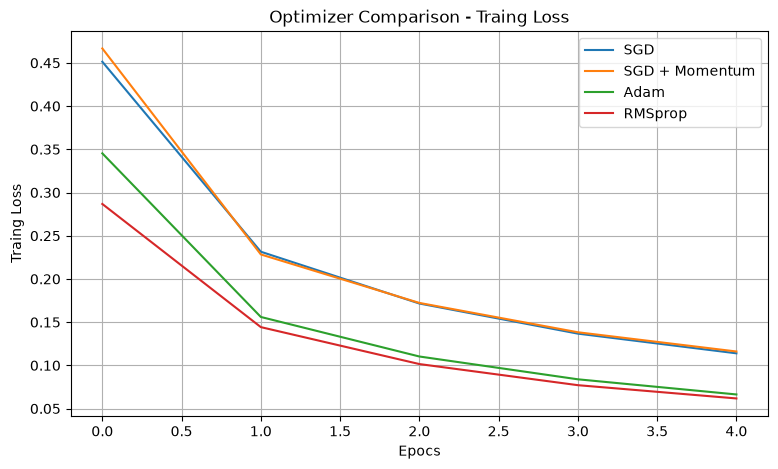

In [59]:
# Compare training loss

import matplotlib.pyplot as plt 

plt.figure(figsize=(9,5))

plt.plot(
    history_sgd["train_loss"],
    label = "SGD"
)


plt.plot(
    history_momentum["train_loss"],
    label = "SGD + Momentum"
)


plt.plot(
    history_adam["train_loss"],
    label = "Adam"
)


plt.plot(
    history_rmsprop["train_loss"],
    label = "RMSprop"
)

plt.xlabel("Epocs")
plt.ylabel("Traing Loss")
plt.title("Optimizer Comparison - Traing Loss")

plt.legend()
plt.grid(True)


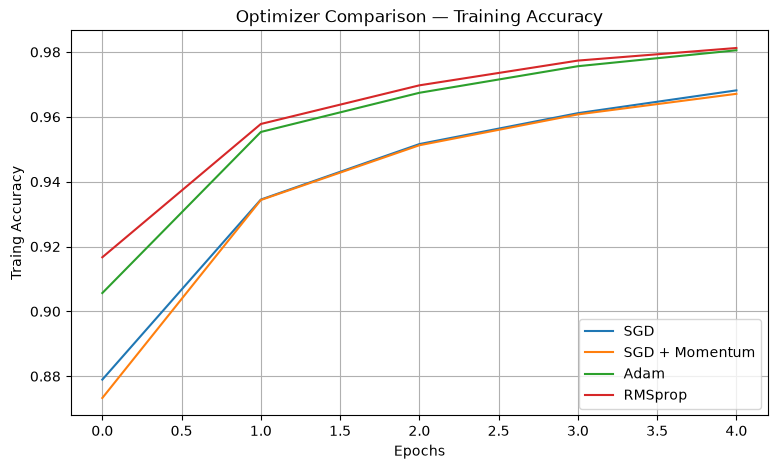

In [60]:
# Compare accuracy

plt.figure(figsize=(9,5))

plt.plot(
    history_sgd["train_accuracy"],
    label = "SGD"
)

plt.plot(
    history_momentum["train_accuracy"],
    label = "SGD + Momentum"
)

plt.plot(
    history_adam["train_accuracy"],
    label = "Adam"
)

plt.plot(
    history_rmsprop["train_accuracy"],
    label = "RMSprop"
)


plt.xlabel("Epochs")
plt.ylabel("Traing Accuracy")
plt.title("Optimizer Comparison — Training Accuracy")

plt.legend()
plt.grid(True)


In [61]:
import mlflow

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("MNIST Optimizer Comparison")


2026/08/10 16:38:09 INFO mlflow.tracking.fluent: Experiment with name 'MNIST Optimizer Comparison' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/4', creation_time=1786360089958, effective_trace_archival_retention=None, experiment_id='4', last_update_time=1786360089958, lifecycle_stage='active', name='MNIST Optimizer Comparison', tags={}, trace_location=None, workspace='default'>

In [64]:
with mlflow.start_run(run_name="Adam"):

    mlflow.log_param("optimizer","Adam")
    mlflow.log_param("learning_rate",0.001)
    mlflow.log_param("batch_size",64)
    mlflow.log_param("epocs",5)

    # Train model here

    mlflow.log_metric(
        "test_accuracy",
        accuracy_adam
    )



🏃 View run Adam at: http://localhost:5000/#/experiments/4/runs/1bab1b8fac084aecb15eee8a5cb38ba0
🧪 View experiment at: http://localhost:5000/#/experiments/4


In [65]:
with mlflow.start_run(run_name="SGD"):

    mlflow.log_param("optimizer","SGD")
    mlflow.log_param("learning_rate",0.01)
    mlflow.log_param("batch_size",64)
    mlflow.log_param("epocs",5)

    # Train model here

    mlflow.log_metric(
        "test_accuracy",
        accuracy_sgd
    )



🏃 View run SGD at: http://localhost:5000/#/experiments/4/runs/b68657a8163849c28546f809715ad9b4
🧪 View experiment at: http://localhost:5000/#/experiments/4


In [67]:

with mlflow.start_run(run_name="SGD + Momentum"):

    mlflow.log_param("optimizer","SGD + Momentum")
    mlflow.log_param("learning_rate",0.01)
    mlflow.log_param("batch_size",64)
    mlflow.log_param("epocs",5)

    # Train model here

    mlflow.log_metric(
        "test_accuracy",
        accuracy_momentum
    )



🏃 View run SGD + Momentum at: http://localhost:5000/#/experiments/4/runs/37db014fc97a4d3fa1399b7f9919b567
🧪 View experiment at: http://localhost:5000/#/experiments/4


In [68]:
with mlflow.start_run(run_name="RMSprop"):

    mlflow.log_param("optimizer","RMSprop")
    mlflow.log_param("learning_rate",0.01)
    mlflow.log_param("batch_size",64)
    mlflow.log_param("epocs",5)

    # Train model here

    mlflow.log_metric(
        "test_accuracy",
        accuracy_rmsprop
    )



🏃 View run RMSprop at: http://localhost:5000/#/experiments/4/runs/1ab0959c336248749255a944415d4b63
🧪 View experiment at: http://localhost:5000/#/experiments/4
